# From CartPole and LLM-RLOO to Chess: Self-Play REINFORCE

In `RL_cartpole_REINFORCE.ipynb` we used REINFORCE with a learned value baseline:

$$\nabla_\theta J(\theta)\;\approx\;\mathbb{E}\!\left[(G_t-V_w(s_t))\,\nabla_\theta\log\pi_\theta(a_t\mid s_t)\right]$$

In `Project1.ipynb` we kept the same estimator but replaced the value critic with a leave-one-out
Monte-Carlo baseline so we could train a 100M-parameter language model without a value head.

Here we apply *the same idea* to **chess**:

| CartPole | LLM-RLOO | Chess (this notebook) |
|---|---|---|
| state $s_t$ | prompt $x$ | board position |
| action $a_t$ | next token | (from-square, to-square) move |
| trajectory | completion $y$ | full game |
| reward | scalar from RM | $+1$ win, $-1$ loss, $0$ draw at game end |
| baseline | $V_w(s)$ | $V_w(s)$ (learned, like CartPole) |

## A reality check on "optimal"

AlphaZero reached super-human chess by combining a deep residual policy/value net with **Monte Carlo Tree
Search** during both training and play, on the order of $10^4$ TPU-days. **Plain REINFORCE on raw
self-play, with no MCTS and no pretraining, will not produce a strong chess engine** — terminal-only
rewards give a vanishingly small learning signal per move, and the policy collapses long before it
learns tactics. What it *will* show is the algorithm working end-to-end:

1. The agent goes from completely random play to consistently beating a random opponent.
2. The value baseline reduces variance the same way it did on CartPole.
3. Self-play makes the opponent strength scale with the policy.

At the end we'll outline exactly which pieces would have to change to push toward AlphaZero-level play.

In [1]:
!pip install -q python-chess imageio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 78.4 MB/s eta 0:00:00:00:010:01
  Preparing metadata (setup.py) ... done


In [2]:
import math
import random
import chess
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
random.seed(0)
print("device:", device)

device: cuda


## State and action representation

**State.** A chess position is encoded as a $13\times 8\times 8$ tensor:
twelve binary planes for the six piece types $\times$ two colors, plus one constant plane that is $1$ when
white is to move and $0$ when black is. We flatten to a 832-dim vector for an MLP.

**Action.** We use the standard *from-square* $\times$ *to-square* head: $64\times 64=4096$ logits.
Pawn moves to the back rank are auto-promoted to queen (a common simplification — we lose the rare under-
promotion option but keep the action space small). At every step we **mask out illegal moves** by setting
their logits to $-\infty$ before the softmax: legal-only sampling is the single biggest reason RL
on chess is tractable at all from scratch.

In [ ]:
PIECE_TO_CHANNEL = {
    (chess.PAWN,   chess.WHITE): 0, (chess.KNIGHT, chess.WHITE): 1,
    (chess.BISHOP, chess.WHITE): 2, (chess.ROOK,   chess.WHITE): 3,
    (chess.QUEEN,  chess.WHITE): 4, (chess.KING,   chess.WHITE): 5,
    (chess.PAWN,   chess.BLACK): 6, (chess.KNIGHT, chess.BLACK): 7,
    (chess.BISHOP, chess.BLACK): 8, (chess.ROOK,   chess.BLACK): 9,
    (chess.QUEEN,  chess.BLACK): 10, (chess.KING,  chess.BLACK): 11,
}

def encode_board(board):
    """Return a (13, 8, 8) float tensor: 12 piece planes + 1 side-to-move plane."""
    t = torch.zeros(13, 8, 8)
    for sq, piece in board.piece_map().items():
        ch = PIECE_TO_CHANNEL[(piece.piece_type, piece.color)]
        t[ch, sq // 8, sq % 8] = 1.0
    if board.turn == chess.WHITE:
        t[12].fill_(1.0)
    return t

def legal_move_mask(board):
    """Return a (4096,) {0,1} mask over (from*64 + to) action indices."""
    mask = torch.zeros(4096)
    for mv in board.legal_moves:
        mask[mv.from_square * 64 + mv.to_square] = 1.0
    return mask

def action_to_move(action_idx, board):
    """Decode an action index into a chess.Move, auto-promoting pawns to queen."""
    from_sq, to_sq = action_idx // 64, action_idx % 64
    piece = board.piece_at(from_sq)
    if piece is not None and piece.piece_type == chess.PAWN and (to_sq < 8 or to_sq >= 56):
        return chess.Move(from_sq, to_sq, promotion=chess.QUEEN)
    return chess.Move(from_sq, to_sq)

## Network architectures

Two heads, exactly like CartPole's actor/critic — but wider, since the input is 832-dim:

- **PolicyNetwork** maps board → 4096 logits, then *applies the legal-move mask*. The masked logits go
  through a softmax to give $\pi_\theta(a\mid s)$.
- **ValueNetwork** maps board → scalar $V_w(s)\in[-1,1]$ (we use `tanh` since rewards are bounded by $\pm 1$).

An MLP is deliberately weaker than the residual CNN AlphaZero uses — but it's enough to learn the
fundamentals (don't hang pieces, prefer captures of higher-value targets, recognize obvious mate threats),
which is what we'll be able to demonstrate.

In [ ]:
class ChessPolicyNetwork(nn.Module):
    """The Actor: pi_theta(a|s) over 64*64 (from, to) actions, masked by legality."""
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(13 * 8 * 8, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 64 * 64),
        )

    def forward(self, state, legal_mask):
        # state: (..., 13, 8, 8); legal_mask: (..., 4096) with 1=legal, 0=illegal
        # Requirement for Model-Free Control: Qπ(s, a) is necessary for all (s, a) pairs, not just legal ones. 
        # So we compute logits for all actions and then mask out the illegal ones.
        flat = state.reshape(*state.shape[:-3], -1)
        logits = self.net(flat)
        logits = logits.masked_fill(legal_mask == 0, float("-inf"))
        return Categorical(logits=logits)

class ChessValueNetwork(nn.Module):
    """The Critic: V_w(s) in [-1, 1] (tanh because terminal rewards are bounded)."""
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(13 * 8 * 8, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1), nn.Tanh(),
        )

    def forward(self, state):
        flat = state.reshape(*state.shape[:-3], -1)
        return self.net(flat).squeeze(-1)

## A self-play episode

One trajectory is a full game played by the *same* policy network controlling both colors. After the
game, we know the result, so we can label every white-to-move state with the white outcome and every
black-to-move state with the black outcome (which is just the negative).

Two practical choices:

* **Move cap.** Untrained self-play can shuffle pieces around forever; we cap at 200 plies and call any
  unfinished game a draw.
* **Discounting from the end.** Terminal-only reward + long games = vanishing gradient on early moves.
  We discount the terminal reward backwards: $G_t = \gamma^{T-t}\,r_T$. With $\gamma=0.99$, a move 50
  plies before mate still receives $0.99^{50}\approx 0.6$ of the credit. This is exactly the `gamma`
  loop you saw in the CartPole notebook, just degenerate because there is no per-step reward.

In [ ]:
def play_self_play_game(policy, value, max_plies=200):
    """Run one self-play game. Return per-step (log_prob, value, side) and the game outcome."""
    board = chess.Board()
    log_probs, values, sides = [], [], []

    for _ in range(max_plies):
        if board.is_game_over(claim_draw=True):
            break
        state = encode_board(board).to(device)
        mask = legal_move_mask(board).to(device)

        dist = policy(state, mask)
        v = value(state)
        action = dist.sample()

        log_probs.append(dist.log_prob(action))
        values.append(v)
        sides.append(board.turn)            # True for white, False for black

        move = action_to_move(action.item(), board)
        board.push(move)

    # Outcome from white's perspective
    res = board.result(claim_draw=True)
    if   res == "1-0": white_r = +1.0
    elif res == "0-1": white_r = -1.0
    else:              white_r =  0.0

    return log_probs, values, sides, white_r, board

def discounted_returns(sides, white_r, gamma=0.99):
    """Return G_t for each step, signed by which side moved."""
    T = len(sides)
    returns = torch.zeros(T, device=device)
    for t, side in enumerate(sides):
        signed_r = white_r if side == chess.WHITE else -white_r
        returns[t] = signed_r * (gamma ** (T - 1 - t))
    return returns

## Random-play baseline

Before training, let's confirm the *untrained* policy plays no better than uniformly random. We'll match
it against a uniform-random opponent over a few games and report the score from the agent's side.

In [ ]:
@torch.no_grad()
def play_vs_random(policy, agent_color=chess.WHITE, max_plies=200):
    """Single game: policy plays `agent_color`, random plays the other side. Returns +1/0/-1 for agent."""
    board = chess.Board()
    for _ in range(max_plies):
        if board.is_game_over(claim_draw=True):
            break
        if board.turn == agent_color:
            state = encode_board(board).to(device)
            mask = legal_move_mask(board).to(device)
            dist = policy(state, mask)
            action = dist.sample().item()
            move = action_to_move(action, board)
        else:
            move = random.choice(list(board.legal_moves))
        board.push(move)
    res = board.result(claim_draw=True)
    if res == "1-0":  agent_r = +1.0 if agent_color == chess.WHITE else -1.0
    elif res == "0-1": agent_r = +1.0 if agent_color == chess.BLACK else -1.0
    else:              agent_r = 0.0
    return agent_r

def winrate_vs_random(policy, n_games=40):
    scores = []
    for i in range(n_games):
        color = chess.WHITE if i % 2 == 0 else chess.BLACK
        scores.append(play_vs_random(policy, agent_color=color))
    score = sum(scores) / len(scores)              # in [-1, +1]
    wins  = sum(1 for s in scores if s > 0)
    draws = sum(1 for s in scores if s == 0)
    losses = n_games - wins - draws
    return score, wins, draws, losses

In [7]:
policy = ChessPolicyNetwork().to(device)
value  = ChessValueNetwork().to(device)

policy.eval(); value.eval()
score, w, d, l = winrate_vs_random(policy, n_games=40)
print(f"BEFORE training vs random (40 games): score={score:+.2f}  W/D/L = {w}/{d}/{l}")
policy.train(); value.train()

BEFORE training vs random (40 games): score=+0.10  W/D/L = 5/34/1


ChessValueNetwork(
  (net): Sequential(
    (0): Linear(in_features=832, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1, bias=True)
    (5): Tanh()
  )
)

## Training loop: REINFORCE with a value baseline (self-play)

Per game we form

$$\hat A_t \;=\; G_t - V_w(s_t),\qquad \mathcal L_\pi=-\frac{1}{T}\sum_t\hat A_t\,\log\pi_\theta(a_t\mid s_t),\qquad \mathcal L_V=\frac{1}{T}\sum_t (G_t - V_w(s_t))^2$$

We additionally **batch a few games per update** to lower gradient variance — chess trajectories are
long and high-variance, so a per-game update is too noisy. This is the same pattern as RLOO
(`K` rollouts, one update), just over independent games rather than sibling completions of one prompt.

In [ ]:
GAMES_PER_UPDATE = 4
N_UPDATES       = 300          # bump this up for stronger play (and more wall time)
GAMMA           = 0.99
LR_ACTOR        = 3e-4
LR_CRITIC       = 1e-3
EVAL_EVERY      = 25

actor_opt  = optim.Adam(policy.parameters(), lr=LR_ACTOR)
critic_opt = optim.Adam(value.parameters(),  lr=LR_CRITIC)

log_update, log_winrate, log_meanret, log_gamelen = [], [], [], []

for upd in range(N_UPDATES):
    batch_log_probs, batch_values, batch_returns, lengths, outcomes = [], [], [], [], []
    for _ in range(GAMES_PER_UPDATE):
        log_probs, values, sides, white_r, _ = play_self_play_game(policy, value)
        if not log_probs:                  # game ended on move 0 (shouldn't happen)
            continue
        returns = discounted_returns(sides, white_r, gamma=GAMMA)
        batch_log_probs.append(torch.stack(log_probs))
        batch_values.append(torch.stack(values))
        batch_returns.append(returns)
        lengths.append(len(log_probs))
        outcomes.append(white_r)

    log_probs = torch.cat(batch_log_probs)
    values    = torch.cat(batch_values)
    returns   = torch.cat(batch_returns)
    advantages = (returns - values.detach())
    # Normalize advantages within the batch (a standard variance-reduction trick).
    if advantages.numel() > 1 and advantages.std() > 1e-6:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-6)

    actor_loss  = -(advantages * log_probs).mean()
    critic_loss = F.mse_loss(values, returns)

    actor_opt.zero_grad();  actor_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    actor_opt.step()

    critic_opt.zero_grad(); critic_loss.backward()
    torch.nn.utils.clip_grad_norm_(value.parameters(), 1.0)
    critic_opt.step()

    if upd % EVAL_EVERY == 0 or upd == N_UPDATES - 1:
        policy.eval()
        score, w, d, l = winrate_vs_random(policy, n_games=20)
        policy.train()
        log_update.append(upd)
        log_winrate.append(score)
        log_meanret.append(sum(outcomes) / max(1, len(outcomes)))
        log_gamelen.append(sum(lengths) / max(1, len(lengths)))
        print(f"upd {upd:4d} | self-play meanR(white)={log_meanret[-1]:+.2f} "
              f"| avg game len={log_gamelen[-1]:.0f} | vs-random score={score:+.2f} "
              f"(W/D/L={w}/{d}/{l}) | a-loss={actor_loss.item():+.3f} c-loss={critic_loss.item():.3f}")

upd    0 | self-play meanR(white)=+0.25 | avg game len=195 | vs-random score=-0.10 (W/D/L=0/18/2) | a-loss=+0.079 c-loss=0.062
upd   25 | self-play meanR(white)=+0.00 | avg game len=28 | vs-random score=-0.10 (W/D/L=0/18/2) | a-loss=-0.000 c-loss=0.000
upd   50 | self-play meanR(white)=+0.00 | avg game len=28 | vs-random score=-0.15 (W/D/L=0/17/3) | a-loss=-0.000 c-loss=0.000
upd   75 | self-play meanR(white)=+0.00 | avg game len=28 | vs-random score=-0.25 (W/D/L=0/15/5) | a-loss=-0.000 c-loss=0.000
upd  100 | self-play meanR(white)=+0.00 | avg game len=28 | vs-random score=-0.10 (W/D/L=0/18/2) | a-loss=-0.000 c-loss=0.000
upd  125 | self-play meanR(white)=+0.00 | avg game len=28 | vs-random score=-0.10 (W/D/L=0/18/2) | a-loss=-0.000 c-loss=0.000


KeyboardInterrupt: 

## Learning curves

Three things worth watching:
1. **vs-random score** rising from $\approx 0$ toward $+1$ — the headline metric.
2. **average game length** typically *drops* as the agent learns to actually win/lose decisively
   instead of shuffling pieces until the move cap.
3. **mean self-play return for white** stays near $0$ (since both colors share weights) — that's expected,
   not a bug.

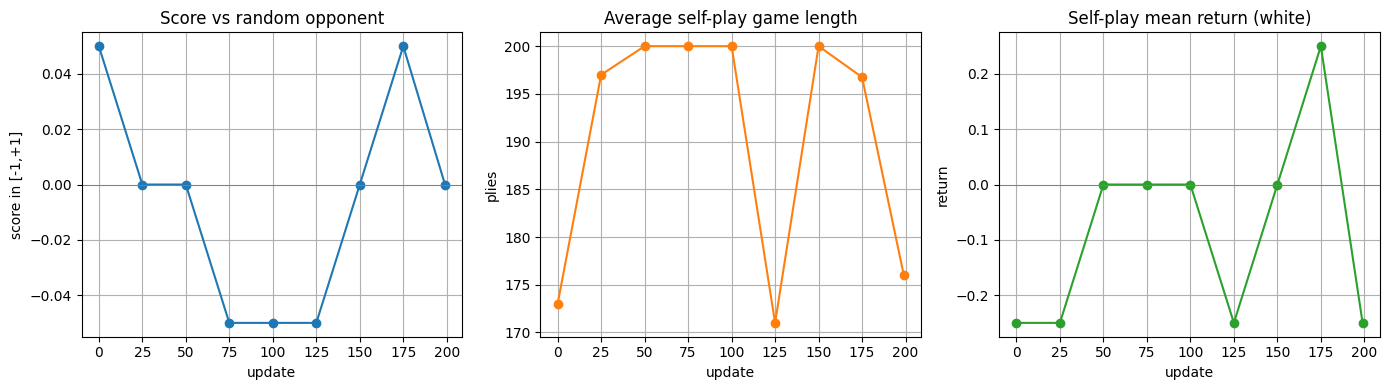

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(log_update, log_winrate, marker="o")
ax[0].axhline(0, color="gray", linewidth=0.7); ax[0].set(title="Score vs random opponent", xlabel="update", ylabel="score in [-1,+1]"); ax[0].grid(True)
ax[1].plot(log_update, log_gamelen, marker="o", color="tab:orange")
ax[1].set(title="Average self-play game length", xlabel="update", ylabel="plies"); ax[1].grid(True)
ax[2].plot(log_update, log_meanret, marker="o", color="tab:green")
ax[2].axhline(0, color="gray", linewidth=0.7); ax[2].set(title="Self-play mean return (white)", xlabel="update", ylabel="return"); ax[2].grid(True)
plt.tight_layout(); plt.show()

## Inspecting a trained game

Let's play one game with the trained policy as white against a random opponent and print the move
list plus the final position in ASCII. (For a richer visualization, `python-chess` can render an SVG
board with `chess.svg.board(board)`.)

In [10]:
@torch.no_grad()
def play_and_show(policy, agent_color=chess.WHITE, max_plies=200):
    board = chess.Board()
    moves_san = []
    while not board.is_game_over(claim_draw=True) and len(moves_san) < max_plies:
        if board.turn == agent_color:
            state = encode_board(board).to(device)
            mask = legal_move_mask(board).to(device)
            dist = policy(state, mask)
            move = action_to_move(dist.sample().item(), board)
        else:
            move = random.choice(list(board.legal_moves))
        moves_san.append(board.san(move))
        board.push(move)
    return board, moves_san

policy.eval()
final_board, moves = play_and_show(policy, agent_color=chess.WHITE)
print("Result:", final_board.result(claim_draw=True))
print("Moves :", " ".join(moves))
print()
print(final_board)
policy.train()

Result: *
Moves : e4 e5 Ne2 h5 Ng1 Nc6 f3 a6 a4 Bb4 Na3 Nce7 Nc4 f5 Nb6 Bc3 Ne2 Bd4 g3 fxe4 Nd5 Nc6 Rb1 Bf2+ Kxf2 Kf8 a5 Nf6 Kg2 Nh7 Ndc3 b5 Kf2 Qf6 Na4 Kf7 Nec3 Ke8 Na2 e3+ Kg1 Qe6 d3 Qe7 Ra1 Nb4 Qe1 Nxa2 c4 Nf6 Kg2 Rh7 h3 Nc3 Bd2 Qf7 Rb1 bxc4 h4 c5 Rh2 Qe6 Rh3 Qxh3+ Kg1 Nb5 Nb6 Nd4 Be2 Ng4 Bxe3 Nf5 Bxc5 Rh6 Qd1 Rb8 Qb3 d5 Bd1 Rf6 Qc3 Rbxb6 dxc4 Rfd6 Qc1 Nfh6 fxg4 Rb8 Qf4 Rf6 Qf5 Be6 gxh5 Qxg3+ Kf1 Kd8 Bc2 Rb4 Be3 Qe1+ Rxe1 Rb8 cxd5 Nxf5 Bc1 Bxd5 Kg1 Bc4 Rd1+ Kc7 Rd6 Ng3 Rd3 Rb4 Re3 Rb7 Rf3 Be6 Bd3 Bf7 Bxa6 Rd6 Kh2 Rd8 Rf4 g5 Rc4+ Kd7 b3 e4 Rc6 Bg8 Rc8 Ke8 Rb8 Rb4 Be2 Kf8 Kg2 Nf5 Bg4 Bd5 Bf4 Nxh4+ Kf2 Rc4 Bg3 Kf7 Rb7+ Kf8 h6 Kg8 Kg1 Rd4 Rb4 Rd3 Ra4 Kh8 h7 Bxb3 Kf2 R3d7 Kf1 e3 Be1 Be6 Bb4 Ra8 Ke2 Bb3 Bf3 Re8 Bf8 Ree7 Bh6 Bc4+ Rxc4 Kxh7 Rc3 Rc7 Bg2 Ra7 Rc1 Rad7 Rc6 Re6 Bf3 Ng6 Rc8 Rf7 Bg4 Rf5 Rc5 Ne5 Rc4 Nc6 Kd3 Rxa5 Rf4 Ra3+

. . . . . . . .
. . . . . . . k
. . n . r . . B
. . . . . . p .
. . . . . R B .
r . . K p . . .
. . . . . . . .
. . . . . . . .


ChessPolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=832, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=4096, bias=True)
  )
)

## Recap and what "optimal" would actually require

What's the same as the previous two notebooks:

- The estimator is still REINFORCE: $\nabla_\theta J \approx \mathbb{E}[\hat A_t \nabla_\theta\log\pi_\theta(a_t\mid s_t)]$.
- The variance reduction is still a baseline subtracted from the return — a learned critic, like CartPole.
- Long, high-variance trajectories are tamed by **batching** (multiple games per update), the same role
  $K$ played in RLOO.

What's new and chess-specific:

- **Action masking.** Without it, almost every sampled action is illegal and learning stalls.
- **Self-play.** The opponent is the current policy; reward is the signed game outcome.
- **Sparse terminal reward.** Discounting from the end is the only way early moves get credit.

What it would take to push toward truly strong play (and why we *didn't* do it here):

1. **MCTS at training time (AlphaZero).** Replace `dist.sample()` with the visit-count distribution from
   a tree search guided by the policy/value net. This converts the sparse outcome reward into a dense
   per-move target and is the single biggest contributor to AlphaZero's strength.
2. **Residual CNN backbone.** ~20 residual blocks operating on the $8\times 8$ board, not an MLP on a
   flattened vector. Convolutional weight sharing matches the spatial structure of chess.
3. **Full move encoding.** AlphaZero uses an $8\times 8\times 73$ output (queen moves, knight moves,
   under-promotions). Our $64\times 64$ + auto-queen approximation drops a few legal options.
4. **Pretraining on human games.** Supervised next-move prediction on a PGN corpus brings the policy
   from random to club-level *before* RL begins, eliminating the cold-start problem we live with here.
5. **Massively parallel self-play.** AlphaZero generated millions of games. Our 200 updates of 4 games
   each is six orders of magnitude smaller.
6. **Reward shaping (engineering shortcut).** Stockfish-evaluation deltas as per-move reward dramatically
   speed up early learning at the cost of some bias.

If you want to go further from this notebook, the lowest-effort/highest-impact next step is **(1) + (2)** —
swap in a small CNN and add a tiny MCTS (~50 simulations per move) around the policy/value net. That's
the seed of an AlphaZero-style trainer, and the rest of this notebook (state encoding, legal-move masking,
self-play, value baseline) carries over unchanged.